<a href="https://colab.research.google.com/github/codecodecode333/lunarlander-rl-comparison/blob/main/lunarlander_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!apt-get update -qq
!apt-get install -y -qq swig

!pip install "box2d-py==2.3.5" "numpy==1.26.4"
!pip install "gymnasium[box2d]==0.29.1" pygame==2.5.2

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

env = gym.make("LunarLander-v2")  # render_mode=None 기본값

print("observation space:", env.observation_space)
print("action space:", env.action_space)


observation space: Box([-1.5       -1.5       -5.        -5.        -3.1415927 -5.
 -0.        -0.       ], [1.5       1.5       5.        5.        3.1415927 5.        1.
 1.       ], (8,), float32)
action space: Discrete(4)


Episode 1: total reward = -75.46
Episode 2: total reward = -166.55
Episode 3: total reward = -132.97
Episode 4: total reward = -63.21
Episode 5: total reward = -127.59
Episode 6: total reward = -71.68
Episode 7: total reward = -151.81
Episode 8: total reward = -102.21
Episode 9: total reward = -226.02
Episode 10: total reward = -180.56
Episode 11: total reward = -266.73
Episode 12: total reward = -142.75
Episode 13: total reward = -105.59
Episode 14: total reward = -179.09
Episode 15: total reward = -179.12
Episode 16: total reward = -201.61
Episode 17: total reward = -133.10
Episode 18: total reward = -154.42
Episode 19: total reward = -82.42
Episode 20: total reward = -108.44
Episode 21: total reward = -108.22
Episode 22: total reward = -102.75
Episode 23: total reward = -140.44
Episode 24: total reward = -193.55
Episode 25: total reward = -298.50
Episode 26: total reward = -126.70
Episode 27: total reward = -142.44
Episode 28: total reward = -100.03
Episode 29: total reward = -110.8

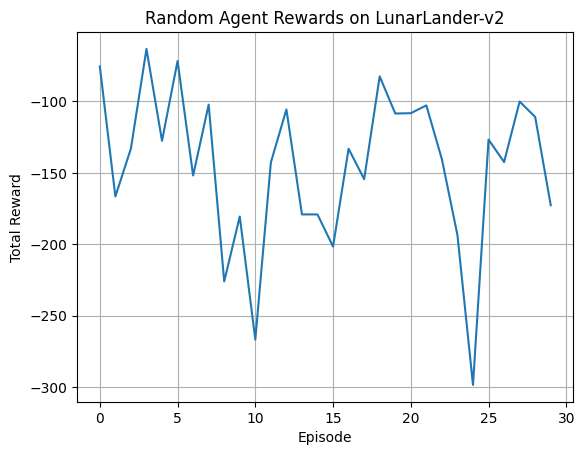

In [ ]:
def run_random_agent(env, n_episodes=20, max_steps=1000):
    episode_rewards = []

    for ep in range(n_episodes):
        obs, info = env.reset()
        total_reward = 0.0

        for t in range(max_steps):
            action = env.action_space.sample()  # 랜덤 액션

            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward

            if terminated or truncated:
                break

        episode_rewards.append(total_reward)
        print(f"Episode {ep+1}: total reward = {total_reward:.2f}")

    return np.array(episode_rewards)

rewards = run_random_agent(env, n_episodes=30)

print("\n==== Random Agent Performance ====")
print(f"Mean reward: {rewards.mean():.2f}")
print(f"Std reward : {rewards.std():.2f}")

plt.figure()
plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Random Agent Rewards on LunarLander-v2")
plt.grid(True)
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

state_dim  = env.observation_space.shape[0]   # 8
action_dim = env.action_space.n               # 4
print("state_dim:", state_dim, "action_dim:", action_dim)


device: cuda
state_dim: 8 action_dim: 4


In [ ]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.net(x)

policy_net = QNetwork(state_dim, action_dim).to(device)
target_net = QNetwork(state_dim, action_dim).to(device)

# 처음엔 두 네트워크를 동일하게 맞춰둔다.
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()  # 타깃 네트워크는 inference 용

optimizer = optim.Adam(policy_net.parameters(), lr=1e-3)
criterion = nn.MSELoss()


In [ ]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.tensor(states, dtype=torch.float32, device=device),
            torch.tensor(actions, dtype=torch.int64, device=device).unsqueeze(-1),
            torch.tensor(rewards, dtype=torch.float32, device=device).unsqueeze(-1),
            torch.tensor(next_states, dtype=torch.float32, device=device),
            torch.tensor(dones, dtype=torch.float32, device=device).unsqueeze(-1),
        )

    def __len__(self):
        return len(self.buffer)

buffer = ReplayBuffer(capacity=50_000)


In [ ]:
# ε-greedy로 액션 선택
def select_action(state, epsilon):
    if random.random() < epsilon:
        return env.action_space.sample()
    else:
        state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            q_values = policy_net(state_t)
        return int(q_values.argmax(dim=1).item())


def train_step(batch_size, gamma):
    if len(buffer) < batch_size:
        return None

    states, actions, rewards, next_states, dones = buffer.sample(batch_size)

    # Q(s,a; policy_net)
    q_values = policy_net(states).gather(1, actions)  # [B,1]

    # max_a' Q_target(s', a')
    with torch.no_grad():
        max_next_q = target_net(next_states).max(dim=1, keepdim=True)[0]
        target = rewards + gamma * (1 - dones) * max_next_q

    loss = criterion(q_values, target)

    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(policy_net.parameters(), 1.0)
    optimizer.step()

    return loss.item()


In [ ]:
num_episodes      = 500
max_steps         = 1000
batch_size        = 64
gamma             = 0.99

eps_start         = 1.0
eps_end           = 0.05
eps_decay_episodes = 300   # 300 에피소드 동안 선형 감소

target_update_interval = 10  # 몇 에피소드마다 target_net 동기화

episode_rewards = []
moving_avg_rewards = []

best_dqn_reward = -1e9
best_dqn_state = None

for episode in range(1, num_episodes + 1):
    state, info = env.reset()
    total_reward = 0.0

    # 에피소드 단위 ε 스케줄
    epsilon = max(eps_end, eps_start - (eps_start - eps_end) * (episode - 1) / eps_decay_episodes)

    for t in range(max_steps):
        action = select_action(state, epsilon)
        next_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated
        buffer.push(state, action, reward, next_state, done)

        state = next_state
        total_reward += reward

        loss = train_step(batch_size, gamma)

        if done:
            break
    #에피소드 저장
    episode_rewards.append(total_reward)

    # 최근 20 에피소드 이동평균
    if len(episode_rewards) >= 20:
        moving_avg = sum(episode_rewards[-20:]) / 20.0
    else:
        moving_avg = sum(episode_rewards) / len(episode_rewards)
    moving_avg_rewards.append(moving_avg)

    # 타깃 네트워크 주기적으로 동기화
    if episode % target_update_interval == 0:
        target_net.load_state_dict(policy_net.state_dict())

    print(f"Ep {episode:3d} | Reward: {total_reward:8.2f} | "
          f"MA(20): {moving_avg:8.2f} | eps={epsilon:.3f}")

    if total_reward > best_dqn_reward:
        best_dqn_reward = total_reward
        best_dqn_state = policy_net.state_dict()
        print(f"[DQN] New best model at Ep {episode}, reward={total_reward:.2f}")


Ep   1 | Reward:  -287.76 | MA(20):  -287.76 | eps=1.000
[DQN] New best model at Ep 1, reward=-287.76
Ep   2 | Reward:  -140.81 | MA(20):  -214.29 | eps=0.997
[DQN] New best model at Ep 2, reward=-140.81
Ep   3 | Reward:  -144.99 | MA(20):  -191.19 | eps=0.994
Ep   4 | Reward:  -326.43 | MA(20):  -225.00 | eps=0.991
Ep   5 | Reward:  -100.75 | MA(20):  -200.15 | eps=0.987
[DQN] New best model at Ep 5, reward=-100.75
Ep   6 | Reward:   -50.39 | MA(20):  -175.19 | eps=0.984
[DQN] New best model at Ep 6, reward=-50.39
Ep   7 | Reward:  -130.82 | MA(20):  -168.85 | eps=0.981
Ep   8 | Reward:  -172.77 | MA(20):  -169.34 | eps=0.978
Ep   9 | Reward:  -423.45 | MA(20):  -197.58 | eps=0.975
Ep  10 | Reward:  -273.02 | MA(20):  -205.12 | eps=0.972
Ep  11 | Reward:  -177.68 | MA(20):  -202.62 | eps=0.968
Ep  12 | Reward:  -155.70 | MA(20):  -198.71 | eps=0.965
Ep  13 | Reward:  -241.69 | MA(20):  -202.02 | eps=0.962
Ep  14 | Reward:  -179.13 | MA(20):  -200.39 | eps=0.959
Ep  15 | Reward:    -6.

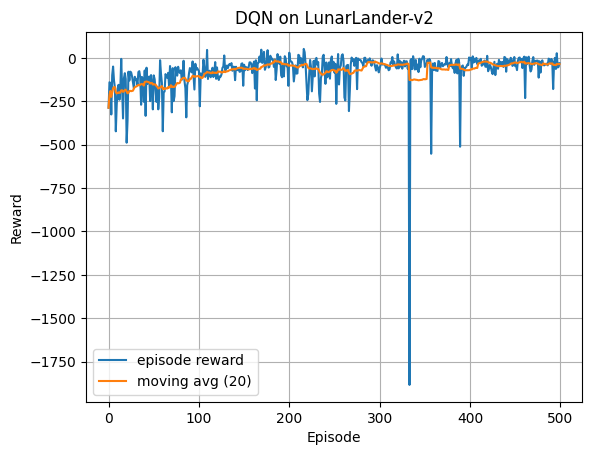

Random agent mean reward   : -221.24
DQN last 100-episode mean  : -34.14601145178673


In [ ]:
plt.figure()
plt.plot(episode_rewards, label="episode reward")
plt.plot(moving_avg_rewards, label="moving avg (20)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("DQN on LunarLander-v2")
plt.legend()
plt.grid(True)
plt.show()

print("Random agent mean reward   :", -221.24)
print("DQN last 100-episode mean  :", sum(episode_rewards[-100:]) / len(episode_rewards[-100:]))


In [ ]:
env_vis = gym.make("LunarLander-v2", render_mode="rgb_array")


In [ ]:
import imageio
import gymnasium as gym
import torch
import numpy as np

def generate_video_with_score(env_name, policy_net, filename="play.mp4", max_steps=1000):
    # env_name (예: "LunarLander-v2")을 받아서 여기서 env를 생성
    env = gym.make(env_name, render_mode="rgb_array")

    frames = []
    total_reward = 0.0

    state, info = env.reset()

    for t in range(max_steps):
        # 프레임 저장
        frame = env.render()
        frames.append(frame)

        # greedy 행동 선택
        state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            action = policy_net(state_t).argmax(dim=1).item()

        next_state, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        state = next_state

        if terminated or truncated:
            break

    env.close()

    # mp4 파일로 저장
    imageio.mimsave(filename, frames, fps=30)
    print(f"Saved video to: {filename}")
    print(f"Episode total reward: {total_reward:.2f}")

    return total_reward


In [ ]:
# Double DQN용 네트워크/옵티마/버퍼 초기화
ddqn_policy_net = QNetwork(state_dim, action_dim).to(device)
ddqn_target_net = QNetwork(state_dim, action_dim).to(device)
ddqn_target_net.load_state_dict(ddqn_policy_net.state_dict())
ddqn_target_net.eval()

ddqn_optimizer = optim.Adam(ddqn_policy_net.parameters(), lr=1e-3)
ddqn_criterion = nn.MSELoss()

ddqn_buffer = ReplayBuffer(capacity=50_000)


In [ ]:
def ddqn_select_action(state, epsilon):
    if random.random() < epsilon:
        return env.action_space.sample()
    else:
        state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            q_values = ddqn_policy_net(state_t)
        return int(q_values.argmax(dim=1).item())


In [ ]:
def ddqn_train_step(batch_size, gamma):
    if len(ddqn_buffer) < batch_size:
        return None

    states, actions, rewards, next_states, dones = ddqn_buffer.sample(batch_size)

    # Q(s,a; policy_net)
    q_values = ddqn_policy_net(states).gather(1, actions)  # [B,1]

    # Double DQN 타깃 계산
    with torch.no_grad():
        # 1) 다음 상태에서 최적 행동은 policy_net으로 선택
        next_q_policy = ddqn_policy_net(next_states)
        next_actions = next_q_policy.argmax(dim=1, keepdim=True)  # [B,1]

        # 2) 그 행동의 Q값은 target_net으로 평가
        next_q_target = ddqn_target_net(next_states).gather(1, next_actions)

        target = rewards + gamma * (1 - dones) * next_q_target

    loss = ddqn_criterion(q_values, target)

    ddqn_optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(ddqn_policy_net.parameters(), 1.0)
    ddqn_optimizer.step()

    return loss.item()


In [ ]:
ddqn_num_episodes       = 500
ddqn_max_steps          = 1000
ddqn_batch_size         = 64
ddqn_gamma              = 0.99

ddqn_eps_start          = 1.0
ddqn_eps_end            = 0.05
ddqn_eps_decay_episodes = 300

ddqn_target_update_interval = 10

ddqn_episode_rewards = []
ddqn_moving_avg_rewards = []

best_ddqn_reward = -1e9
best_ddqn_state = None


for episode in range(1, ddqn_num_episodes + 1):
    state, info = env.reset()
    total_reward = 0.0

    epsilon = max(
        ddqn_eps_end,
        ddqn_eps_start - (ddqn_eps_start - ddqn_eps_end) * (episode - 1) / ddqn_eps_decay_episodes
    )

    for t in range(ddqn_max_steps):
        action = ddqn_select_action(state, epsilon)
        next_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated
        ddqn_buffer.push(state, action, reward, next_state, done)

        state = next_state
        total_reward += reward

        loss = ddqn_train_step(ddqn_batch_size, ddqn_gamma)

        if done:
            break
     #에피소드 저장
    ddqn_episode_rewards.append(total_reward)

    if len(ddqn_episode_rewards) >= 20:
        moving_avg = sum(ddqn_episode_rewards[-20:]) / 20.0
    else:
        moving_avg = sum(ddqn_episode_rewards) / len(ddqn_episode_rewards)
    ddqn_moving_avg_rewards.append(moving_avg)

    if episode % ddqn_target_update_interval == 0:
        ddqn_target_net.load_state_dict(ddqn_policy_net.state_dict())

    print(f"[DDQN] Ep {episode:3d} | Reward: {total_reward:8.2f} | "
          f"MA(20): {moving_avg:8.2f} | eps={epsilon:.3f}")



    if total_reward > best_ddqn_reward:
        best_ddqn_reward = total_reward
        best_ddqn_state = ddqn_policy_net.state_dict()
        print(f"[DDQN] New best model at Ep {episode}, reward={total_reward:.2f}")


[DDQN] Ep   1 | Reward:   -77.01 | MA(20):   -77.01 | eps=1.000
[DDQN] New best model at Ep 1, reward=-77.01
[DDQN] Ep   2 | Reward:  -277.20 | MA(20):  -177.11 | eps=0.997
[DDQN] Ep   3 | Reward:  -119.84 | MA(20):  -158.02 | eps=0.994
[DDQN] Ep   4 | Reward:  -138.70 | MA(20):  -153.19 | eps=0.991
[DDQN] Ep   5 | Reward:   -74.75 | MA(20):  -137.50 | eps=0.987
[DDQN] New best model at Ep 5, reward=-74.75
[DDQN] Ep   6 | Reward:  -345.61 | MA(20):  -172.19 | eps=0.984
[DDQN] Ep   7 | Reward:   -80.43 | MA(20):  -159.08 | eps=0.981
[DDQN] Ep   8 | Reward:  -351.02 | MA(20):  -183.07 | eps=0.978
[DDQN] Ep   9 | Reward:   -81.62 | MA(20):  -171.80 | eps=0.975
[DDQN] Ep  10 | Reward:  -293.76 | MA(20):  -183.99 | eps=0.972
[DDQN] Ep  11 | Reward:  -166.52 | MA(20):  -182.41 | eps=0.968
[DDQN] Ep  12 | Reward:  -112.91 | MA(20):  -176.61 | eps=0.965
[DDQN] Ep  13 | Reward:  -156.02 | MA(20):  -175.03 | eps=0.962
[DDQN] Ep  14 | Reward:   -74.17 | MA(20):  -167.83 | eps=0.959
[DDQN] New bes

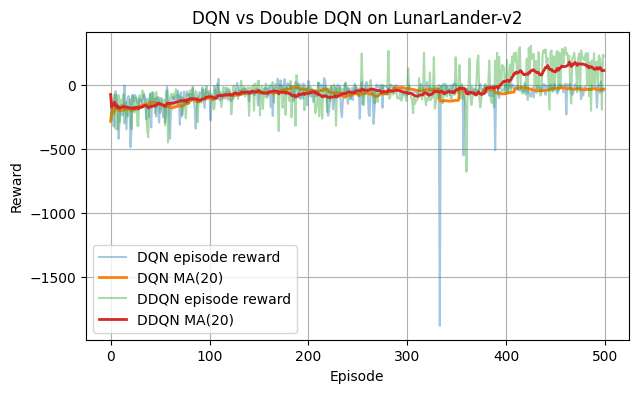

Random agent mean reward       : -221.24
DQN last 100-episode mean      : -34.14601145178673
DDQN last 100-episode mean     : 122.12938044631719


In [ ]:
plt.figure(figsize=(7,4))
plt.plot(episode_rewards, label="DQN episode reward", alpha=0.4)
plt.plot(moving_avg_rewards, label="DQN MA(20)", linewidth=2)

plt.plot(ddqn_episode_rewards, label="DDQN episode reward", alpha=0.4)
plt.plot(ddqn_moving_avg_rewards, label="DDQN MA(20)", linewidth=2)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("DQN vs Double DQN on LunarLander-v2")
plt.legend()
plt.grid(True)
plt.show()

print("Random agent mean reward       :", -221.24)
print("DQN last 100-episode mean      :", sum(episode_rewards[-100:]) / len(episode_rewards[-100:]))
print("DDQN last 100-episode mean     :", sum(ddqn_episode_rewards[-100:]) / len(ddqn_episode_rewards[-100:]))


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class DuelingQNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()

        # 공통 Feature Extractor
        self.feature = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU()
        )

        # V(s): State Value Stream
        self.value_stream = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

        # A(s, a): Advantage Stream
        self.advantage_stream = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x):
        x = self.feature(x)

        value = self.value_stream(x)                # [B, 1]
        advantage = self.advantage_stream(x)        # [B, action_dim]

        # Q(s,a) = V(s) + A(s,a) - mean(A(s,a))
        q_values = value + advantage - advantage.mean(dim=1, keepdim=True)
        return q_values


In [ ]:
dueling_policy_net = DuelingQNetwork(state_dim, action_dim).to(device)
dueling_target_net = DuelingQNetwork(state_dim, action_dim).to(device)

dueling_target_net.load_state_dict(dueling_policy_net.state_dict())
dueling_target_net.eval()

dueling_optimizer = optim.Adam(dueling_policy_net.parameters(), lr=1e-3)
dueling_criterion = nn.MSELoss()


In [ ]:
def dueling_select_action(state, epsilon):
    if random.random() < epsilon:
        return env.action_space.sample()
    else:
        state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            q_values = dueling_policy_net(state_t)
        return int(q_values.argmax(dim=1).item())


In [ ]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.tensor(states, dtype=torch.float32, device=device),
            torch.tensor(actions, dtype=torch.int64, device=device).unsqueeze(-1),
            torch.tensor(rewards, dtype=torch.float32, device=device).unsqueeze(-1),
            torch.tensor(next_states, dtype=torch.float32, device=device),
            torch.tensor(dones, dtype=torch.float32, device=device).unsqueeze(-1),
        )

    def __len__(self):
        return len(self.buffer)

dueling_buffer = ReplayBuffer(50_000)


In [ ]:
def dueling_train_step(batch_size, gamma):
    if len(dueling_buffer) < batch_size:
        return None

    states, actions, rewards, next_states, dones = dueling_buffer.sample(batch_size)

    # Q(s,a; policy)
    q_values = dueling_policy_net(states).gather(1, actions)  # [B,1]

    # Target: r + γ * max_a' Q_target(s', a')
    with torch.no_grad():
        next_q = dueling_target_net(next_states)               # [B, action_dim]
        max_next_q = next_q.max(dim=1, keepdim=True)[0]        # [B,1]

        target = rewards + gamma * (1 - dones) * max_next_q

    loss = dueling_criterion(q_values, target)

    dueling_optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(dueling_policy_net.parameters(), 1.0)
    dueling_optimizer.step()

    return loss.item()


In [ ]:
dueling_num_episodes = 500
dueling_batch_size = 64
dueling_gamma = 0.99

eps_start = 1.0
eps_end = 0.05
eps_decay_episodes = 300

target_update_interval = 10

dueling_episode_rewards = []
dueling_moving_avg = []

best_duel_reward = -1e9
best_duel_state = None

for episode in range(1, dueling_num_episodes + 1):
    state, info = env.reset()
    total_reward = 0.0

    epsilon = max(eps_end, eps_start - (eps_start - eps_end) * (episode - 1) / eps_decay_episodes)

    for t in range(1000):
        action = dueling_select_action(state, epsilon)

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        dueling_buffer.push(state, action, reward, next_state, done)

        state = next_state
        total_reward += reward

        loss = dueling_train_step(dueling_batch_size, dueling_gamma)

        if done:
            break

    #에피소드 저장

    dueling_episode_rewards.append(total_reward)

    if len(dueling_episode_rewards) >= 20:
        avg20 = sum(dueling_episode_rewards[-20:]) / 20
    else:
        avg20 = sum(dueling_episode_rewards) / len(dueling_episode_rewards)

    dueling_moving_avg.append(avg20)

    if episode % target_update_interval == 0:
        dueling_target_net.load_state_dict(dueling_policy_net.state_dict())

    print(f"[Dueling DQN] Ep {episode:3d} | Reward: {total_reward:8.2f} | MA(20): {avg20:8.2f} | eps={epsilon:.3f}")



    if total_reward > best_duel_reward:
        best_duel_reward = total_reward
        best_duel_state = dueling_policy_net.state_dict()
        print(f"[Dueling] New best model at Ep {episode}, reward={total_reward:.2f}")


[Dueling DQN] Ep   1 | Reward:  -341.84 | MA(20):  -341.84 | eps=1.000
[Dueling] New best model at Ep 1, reward=-341.84
[Dueling DQN] Ep   2 | Reward:  -116.61 | MA(20):  -229.22 | eps=0.997
[Dueling] New best model at Ep 2, reward=-116.61
[Dueling DQN] Ep   3 | Reward:  -179.97 | MA(20):  -212.80 | eps=0.994
[Dueling DQN] Ep   4 | Reward:  -116.98 | MA(20):  -188.85 | eps=0.991
[Dueling DQN] Ep   5 | Reward:  -162.09 | MA(20):  -183.50 | eps=0.987
[Dueling DQN] Ep   6 | Reward:  -369.64 | MA(20):  -214.52 | eps=0.984
[Dueling DQN] Ep   7 | Reward:  -200.86 | MA(20):  -212.57 | eps=0.981
[Dueling DQN] Ep   8 | Reward:   -84.91 | MA(20):  -196.61 | eps=0.978
[Dueling] New best model at Ep 8, reward=-84.91
[Dueling DQN] Ep   9 | Reward:   -74.03 | MA(20):  -182.99 | eps=0.975
[Dueling] New best model at Ep 9, reward=-74.03
[Dueling DQN] Ep  10 | Reward:  -121.25 | MA(20):  -176.82 | eps=0.972
[Dueling DQN] Ep  11 | Reward:   -39.72 | MA(20):  -164.35 | eps=0.968
[Dueling] New best model 

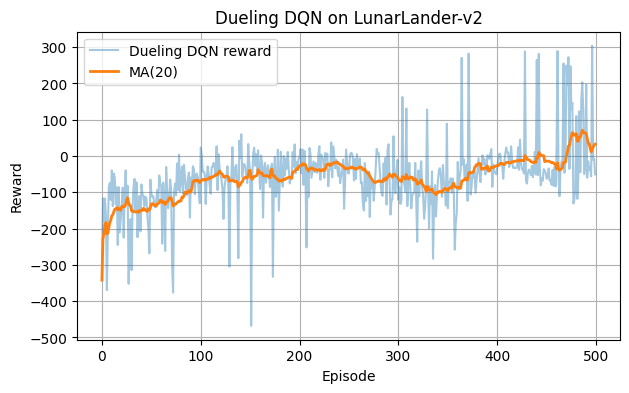

Dueling DQN last 100 mean reward: 7.108534539592752


In [ ]:
plt.figure(figsize=(7,4))
plt.plot(dueling_episode_rewards, label="Dueling DQN reward", alpha=0.4)
plt.plot(dueling_moving_avg, label="MA(20)", linewidth=2)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Dueling DQN on LunarLander-v2")
plt.legend()
plt.grid(True)
plt.show()

print("Dueling DQN last 100 mean reward:",
      sum(dueling_episode_rewards[-100:]) / 100)


In [ ]:
d3qn_policy_net = DuelingQNetwork(state_dim, action_dim).to(device)
d3qn_target_net = DuelingQNetwork(state_dim, action_dim).to(device)

d3qn_target_net.load_state_dict(d3qn_policy_net.state_dict())
d3qn_target_net.eval()

d3qn_optimizer = optim.Adam(d3qn_policy_net.parameters(), lr=1e-3)
d3qn_criterion = nn.MSELoss()

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.tensor(states, dtype=torch.float32, device=device),
            torch.tensor(actions, dtype=torch.int64, device=device).unsqueeze(-1),
            torch.tensor(rewards, dtype=torch.float32, device=device).unsqueeze(-1),
            torch.tensor(next_states, dtype=torch.float32, device=device),
            torch.tensor(dones, dtype=torch.float32, device=device).unsqueeze(-1),
        )

    def __len__(self):
        return len(self.buffer)

d3qn_buffer = ReplayBuffer(50_000)


In [ ]:
def d3qn_select_action(state, epsilon):
    if random.random() < epsilon:
        return env.action_space.sample()
    else:
        state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            q_values = d3qn_policy_net(state_t)
        return int(q_values.argmax(dim=1).item())


In [ ]:
def d3qn_train_step(batch_size, gamma):
    if len(d3qn_buffer) < batch_size:
        return None

    states, actions, rewards, next_states, dones = d3qn_buffer.sample(batch_size)

    # Q(s,a; policy_net)
    q_values = d3qn_policy_net(states).gather(1, actions)  # [B,1]

    # ------- Double DQN Target -------
    with torch.no_grad():
        # 1) 다음 상태에서 최적 행동은 policy_net으로 선택
        next_q_policy = d3qn_policy_net(next_states)                     # [B, A]
        next_actions = next_q_policy.argmax(dim=1, keepdim=True)        # [B,1]

        # 2) 그 행동의 Q값은 target_net으로 평가
        next_q_target_all = d3qn_target_net(next_states)                # [B, A]
        next_q_target = next_q_target_all.gather(1, next_actions)       # [B,1]

        target = rewards + gamma * (1 - dones) * next_q_target
    # ----------------------------------

    loss = d3qn_criterion(q_values, target)

    d3qn_optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(d3qn_policy_net.parameters(), 1.0)
    d3qn_optimizer.step()

    return loss.item()


In [ ]:
d3qn_num_episodes = 500
d3qn_max_steps = 1000
d3qn_batch_size = 64
d3qn_gamma = 0.99

d3qn_eps_start = 1.0
d3qn_eps_end = 0.05
d3qn_eps_decay_episodes = 300

d3qn_target_update_interval = 10

d3qn_episode_rewards = []
d3qn_moving_avg = []

best_d3qn_reward = -1e9
best_d3qn_state = None


for episode in range(1, d3qn_num_episodes + 1):
    state, info = env.reset()
    total_reward = 0.0

    epsilon = max(
        d3qn_eps_end,
        d3qn_eps_start - (d3qn_eps_start - d3qn_eps_end) * (episode - 1) / d3qn_eps_decay_episodes
    )

    for t in range(d3qn_max_steps):
        action = d3qn_select_action(state, epsilon)
        next_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated
        d3qn_buffer.push(state, action, reward, next_state, done)

        state = next_state
        total_reward += reward

        loss = d3qn_train_step(d3qn_batch_size, d3qn_gamma)

        if done:
            break

    #에피소드 저장
    d3qn_episode_rewards.append(total_reward)


    if len(d3qn_episode_rewards) >= 20:
        ma20 = sum(d3qn_episode_rewards[-20:]) / 20.0
    else:
        ma20 = sum(d3qn_episode_rewards) / len(d3qn_episode_rewards)
    d3qn_moving_avg.append(ma20)

    if episode % d3qn_target_update_interval == 0:
        d3qn_target_net.load_state_dict(d3qn_policy_net.state_dict())

    print(f"[D3QN] Ep {episode:3d} | Reward: {total_reward:8.2f} | MA(20): {ma20:8.2f} | eps={epsilon:.3f}")


    if total_reward > best_d3qn_reward:
        best_d3qn_reward = total_reward
        best_d3qn_state = d3qn_policy_net.state_dict()
        print(f"[D3QN] New best model at Ep {episode}, reward={total_reward:.2f}")


[D3QN] Ep   1 | Reward:  -128.03 | MA(20):  -128.03 | eps=1.000
[D3QN] New best model at Ep 1, reward=-128.03
[D3QN] Ep   2 | Reward:  -195.49 | MA(20):  -161.76 | eps=0.997
[D3QN] Ep   3 | Reward:   -87.60 | MA(20):  -137.04 | eps=0.994
[D3QN] New best model at Ep 3, reward=-87.60
[D3QN] Ep   4 | Reward:   -53.09 | MA(20):  -116.05 | eps=0.991
[D3QN] New best model at Ep 4, reward=-53.09
[D3QN] Ep   5 | Reward:  -321.47 | MA(20):  -157.14 | eps=0.987
[D3QN] Ep   6 | Reward:  -252.58 | MA(20):  -173.04 | eps=0.984
[D3QN] Ep   7 | Reward:  -182.82 | MA(20):  -174.44 | eps=0.981
[D3QN] Ep   8 | Reward:  -297.40 | MA(20):  -189.81 | eps=0.978
[D3QN] Ep   9 | Reward:   -61.53 | MA(20):  -175.56 | eps=0.975
[D3QN] Ep  10 | Reward:   -40.08 | MA(20):  -162.01 | eps=0.972
[D3QN] New best model at Ep 10, reward=-40.08
[D3QN] Ep  11 | Reward:  -112.24 | MA(20):  -157.48 | eps=0.968
[D3QN] Ep  12 | Reward:  -334.67 | MA(20):  -172.25 | eps=0.965
[D3QN] Ep  13 | Reward:   -60.49 | MA(20):  -163.6

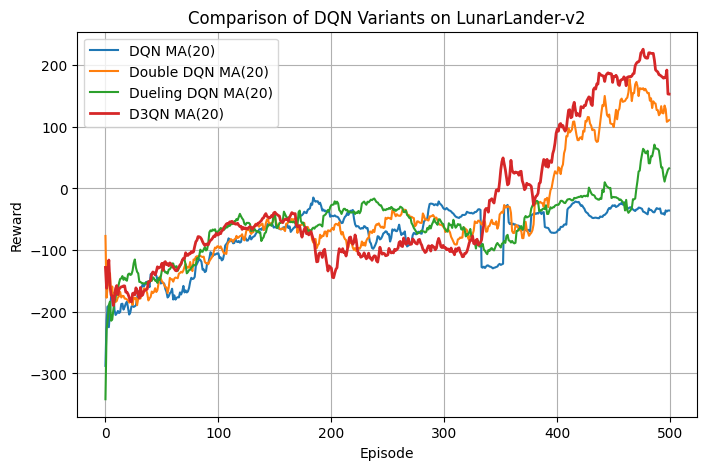

In [ ]:
plt.figure(figsize=(8,5))

# 필요할 때만 주석 해제해서 사용
plt.plot(moving_avg_rewards, label="DQN MA(20)")
plt.plot(ddqn_moving_avg_rewards, label="Double DQN MA(20)")
plt.plot(dueling_moving_avg, label="Dueling DQN MA(20)")
plt.plot(d3qn_moving_avg, label="D3QN MA(20)", linewidth=2)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Comparison of DQN Variants on LunarLander-v2")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import imageio
import gymnasium as gym
import torch
import numpy as np

def record_best_episode(env_name, policy_net, filename="best_episode.mp4",
                        n_episodes=100, max_steps=1000):
    """
    env_name: 예) "LunarLander-v2"
    policy_net: 학습된 Q 네트워크 (DQN, D3QN 등)
    filename: 저장할 mp4 파일명
    n_episodes: 몇 개 에피소드를 돌려서 그중 최고 리워드를 뽑을지
    """
    env = gym.make(env_name, render_mode="rgb_array")

    best_reward = -1e9
    best_frames = None

    for ep in range(1, n_episodes + 1):
        state, info = env.reset()
        frames = []
        total_reward = 0.0

        for t in range(max_steps):
            frame = env.render()
            frames.append(frame)

            # greedy 정책 (탐색 없이)
            state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                action = policy_net(state_t).argmax(dim=1).item()

            next_state, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            state = next_state

            if terminated or truncated:
                break

        print(f"[Eval] Episode {ep}/{n_episodes} | reward = {total_reward:.2f}")

        # 최고 리워드 에피소드 갱신
        if total_reward > best_reward:
            best_reward = total_reward
            best_frames = frames

    env.close()

    # 최고 에피소드만 영상으로 저장
    if best_frames is not None:
        imageio.mimsave(filename, best_frames, fps=30)
        print(f"\nSaved BEST episode video to: {filename}")
        print(f"Best episode reward: {best_reward:.2f}")
    else:
        print("No frames recorded; something went wrong.")

    return best_reward


In [ ]:
# 최고 성능 모델 로드
d3qn_policy_net.load_state_dict(best_d3qn_state)

# 그 상태의 모델로 다시 여러 에피소드를 돌려서 best episode 녹화
record_best_episode("LunarLander-v2", d3qn_policy_net,
                    filename="d3qn_best_from_best_model.mp4", n_episodes=10)


[Eval] Episode 1/10 | reward = 36.21
[Eval] Episode 2/10 | reward = -0.22
[Eval] Episode 3/10 | reward = -5.89
[Eval] Episode 4/10 | reward = 22.47
[Eval] Episode 5/10 | reward = -26.29
[Eval] Episode 6/10 | reward = -3.24
[Eval] Episode 7/10 | reward = 4.51
[Eval] Episode 8/10 | reward = 12.82
[Eval] Episode 9/10 | reward = -19.22


[Eval] Episode 10/10 | reward = 261.82

Saved BEST episode video to: d3qn_best_from_best_model.mp4
Best episode reward: 261.82


261.82477959777793

In [ ]:
# 최고 성능 모델 로드
ddqn_policy_net.load_state_dict(best_ddqn_state)

# 그 상태의 모델로 다시 여러 에피소드를 돌려서 best episode 녹화
record_best_episode("LunarLander-v2", ddqn_policy_net,
                    filename="ddqn_best_from_best_model.mp4", n_episodes=10)


[Eval] Episode 1/10 | reward = 233.88
[Eval] Episode 2/10 | reward = 171.20
[Eval] Episode 3/10 | reward = 243.90
[Eval] Episode 4/10 | reward = -54.19
[Eval] Episode 5/10 | reward = -60.13
[Eval] Episode 6/10 | reward = -71.55
[Eval] Episode 7/10 | reward = 237.17
[Eval] Episode 8/10 | reward = -83.87
[Eval] Episode 9/10 | reward = 222.35


[Eval] Episode 10/10 | reward = -48.12

Saved BEST episode video to: ddqn_best_from_best_model.mp4
Best episode reward: 243.90


243.89763699793718

In [ ]:
# 최고 성능 모델 로드
dueling_policy_net.load_state_dict(best_duel_state)

# 그 상태의 모델로 다시 여러 에피소드를 돌려서 best episode 녹화
record_best_episode("LunarLander-v2", dueling_policy_net,
                    filename="dueling_best_from_best_model.mp4", n_episodes=10)


[Eval] Episode 1/10 | reward = -77.28
[Eval] Episode 2/10 | reward = -5.97
[Eval] Episode 3/10 | reward = -39.68
[Eval] Episode 4/10 | reward = -10.05
[Eval] Episode 5/10 | reward = -37.21
[Eval] Episode 6/10 | reward = -21.92
[Eval] Episode 7/10 | reward = -60.17
[Eval] Episode 8/10 | reward = 7.17
[Eval] Episode 9/10 | reward = -48.28


[Eval] Episode 10/10 | reward = -77.17

Saved BEST episode video to: dueling_best_from_best_model.mp4
Best episode reward: 7.17


7.171778374424446

In [ ]:
# 최고 성능 모델 로드
policy_net.load_state_dict(best_dqn_state)

# 그 상태의 모델로 다시 여러 에피소드를 돌려서 best episode 녹화
record_best_episode("LunarLander-v2", policy_net,
                    filename="dqn_best_from_best_model.mp4", n_episodes=10)


[Eval] Episode 1/10 | reward = 5.95
[Eval] Episode 2/10 | reward = -19.50
[Eval] Episode 3/10 | reward = 4.90
[Eval] Episode 4/10 | reward = -8.36
[Eval] Episode 5/10 | reward = -0.99
[Eval] Episode 6/10 | reward = 6.02
[Eval] Episode 7/10 | reward = -41.21
[Eval] Episode 8/10 | reward = -2.13
[Eval] Episode 9/10 | reward = -9.06


[Eval] Episode 10/10 | reward = -26.46

Saved BEST episode video to: dqn_best_from_best_model.mp4
Best episode reward: 6.02


6.0182066902173945

In [ ]:
import torch
import numpy as np
import gymnasium as gym

# ============ 평가 함수 ============
def evaluate_model(env_name, model, episodes=100, device="cpu"):
    env = gym.make(env_name)
    rewards = []

    for _ in range(episodes):
        state, _ = env.reset()
        total = 0
        done = False

        while not done:
            with torch.no_grad():
                s = torch.FloatTensor(state).unsqueeze(0).to(device)
                q = model(s)
                action = q.argmax(dim=1).item()

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            total += reward
            state = next_state

        rewards.append(total)

    env.close()
    return np.mean(rewards), rewards


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) 네트워크 구조 불러오기
# 너의 코드 기준 (추가 수정 필요 없음)

dqn_model     = QNetwork(state_dim, action_dim).to(device)
ddqn_model    = QNetwork(state_dim, action_dim).to(device)
duel_model    = DuelingQNetwork(state_dim, action_dim).to(device)
d3qn_model    = DuelingQNetwork(state_dim, action_dim).to(device)

# 2) 저장된 best 모델 로드
dqn_model.load_state_dict(best_dqn_state)
ddqn_model.load_state_dict(best_ddqn_state)
duel_model.load_state_dict(best_duel_state)
d3qn_model.load_state_dict(best_d3qn_state)

# 3) 평가 실행
dqn_mean,  dqn_all   = evaluate_model("LunarLander-v2", dqn_model, device=device)
ddqn_mean, ddqn_all  = evaluate_model("LunarLander-v2", ddqn_model, device=device)
duel_mean, duel_all  = evaluate_model("LunarLander-v2", duel_model, device=device)
d3qn_mean, d3qn_all  = evaluate_model("LunarLander-v2", d3qn_model, device=device)


# 4) 결과 출력
print("=== Evaluation Results ===")
print(f"DQN   Mean Reward : {dqn_mean:.2f}")
print(f"DDQN  Mean Reward : {ddqn_mean:.2f}")
print(f"Dueling Mean Reward : {duel_mean:.2f}")
print(f"D3QN   Mean Reward : {d3qn_mean:.2f}")

print("\nRaw rewards (each episode):")
print("DQN:", dqn_all)
print("DDQN:", ddqn_all)
print("Dueling:", duel_all)
print("D3QN:", d3qn_all)


=== Evaluation Results ===
DQN   Mean Reward : -27.74
DDQN  Mean Reward : 61.05
Dueling Mean Reward : -8.36
D3QN   Mean Reward : 26.68

Raw rewards (each episode):
DQN: [-54.01114827429793, -12.521489862912956, -18.370406201763004, -69.91544312608467, -50.95094129585216, -22.243380571284924, -16.12669678943941, -17.534323033444547, -18.596140330633588, -14.836089774262415, -1.720230865967934, -39.46505596727806, -44.61820899348136, 0.24900772830086004, -110.54565148981101, 7.358506525636663, -54.0819018465772, -20.166545444660755, -17.71794202854859, -52.40207347234295, -3.3274352177574658, -28.59420266621094, -6.386566412730749, 12.471703577037575, -24.650364153498238, -32.80555657688214, -18.72347027016789, -55.04251360536713, 3.647022743198295, -48.243709644789035, -36.28590074828884, -34.24257466091764, 2.126687460849796, -4.284919837110831, -1.5428127985947049, -66.78120885220676, -16.4132132549247, -36.5574161649284, -7.313823148600422, 10.527305081417548, -41.73992015273335, -42

In [ ]:
def last_100_mean(episode_rewards):
    if len(episode_rewards) >= 100:
        return sum(episode_rewards[-100:]) / 100.0
    else:
        return sum(episode_rewards) / len(episode_rewards)

dqn_last100   = last_100_mean(episode_rewards)
ddqn_last100  = last_100_mean(ddqn_episode_rewards)
duel_last100  = last_100_mean(dueling_episode_rewards)
d3qn_last100  = last_100_mean(d3qn_episode_rewards)

print("DQN  last 100-ep mean:", dqn_last100)
print("DDQN last 100-ep mean:", ddqn_last100)
print("Duel last 100-ep mean:", duel_last100)
print("D3QN last 100-ep mean:", d3qn_last100)


DQN  last 100-ep mean: -34.14601145178673
DDQN last 100-ep mean: 122.12938044631719
Duel last 100-ep mean: 7.108534539592752
D3QN last 100-ep mean: 169.61269425289487
